# Введение в машинное обучение, АБД

## НИУ ВШЭ, 2025-26 учебный год

# Домашнее задание 2. Часть 2. Полносвязные нейронные сети

Задание выполнил(а):

**Кулешова Анастасия**

## Общая информация

__Внимание!__  

* Домашнее задание выполняется самостоятельно
* Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов
* Использование в решении домашнего задания за рамками справочной и образовательной информации генеративных моделей (ChatGPT и так далее) для генерации кода задания считается плагиатом, и такое домашнее задание оценивается в 0 баллов

**Примечание**

В каждой части оцениваются как код, **так и ответы на вопросы.** Вопросы подсвечены синим цветом.

Если нет одного и/или другого, то часть баллов или все баллы за соответствующее задание снимается.

### О задании

В этом задании вам предстоит обучить полносвязную нейронную сеть для предсказания года выпуска песни по ее аудио-признакам. Для этого мы будем использовать [Million Songs Dataset](https://samyzaf.com/ML/song_year/song_year.html).

## Импорт библиотек, загрузка данных

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import clear_output
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm

In [33]:
plt.rcParams.update({"font.size": 16})
sns.set_style("whitegrid")
np.random.seed(0xFA1AFE1)

Начнем с того, что скачаем и загрузим данные:

In [34]:
!wget -O data.txt.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip

--2026-06-24 10:26:20--  https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘data.txt.zip’

data.txt.zip            [             <=>    ] 201.24M  54.2MB/s    in 4.3s    

2026-06-24 10:26:24 (47.2 MB/s) - ‘data.txt.zip’ saved [211011981]



In [35]:
df = pd.read_csv("data.txt.zip", header=None)
df

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515340,2006,51.28467,45.88068,22.19582,-5.53319,-3.61835,-16.36914,2.12652,5.18160,-8.66890,...,4.81440,-3.75991,-30.92584,26.33968,-5.03390,21.86037,-142.29410,3.42901,-41.14721,-15.46052
515341,2006,49.87870,37.93125,18.65987,-3.63581,-27.75665,-18.52988,7.76108,3.56109,-2.50351,...,32.38589,-32.75535,-61.05473,56.65182,15.29965,95.88193,-10.63242,12.96552,92.11633,10.88815
515342,2006,45.12852,12.65758,-38.72018,8.80882,-29.29985,-2.28706,-18.40424,-22.28726,-4.52429,...,-18.73598,-71.15954,-123.98443,121.26989,10.89629,34.62409,-248.61020,-6.07171,53.96319,-8.09364
515343,2006,44.16614,32.38368,-3.34971,-2.49165,-19.59278,-18.67098,8.78428,4.02039,-12.01230,...,67.16763,282.77624,-4.63677,144.00125,21.62652,-29.72432,71.47198,20.32240,14.83107,39.74909


Посмотрим на статистики по данным.

In [36]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
count,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,...,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000
mean,1998.397082,43.387126,1.289554,8.658347,1.164124,-6.553601,-9.521975,-2.391089,-1.793236,3.727876,...,15.755406,-73.461500,41.542422,37.934119,0.315751,17.669213,-26.315336,4.458641,20.035136,1.329105
std,10.931046,6.067558,51.580351,35.268585,16.322790,22.860785,12.857751,14.571873,7.963827,10.582861,...,32.099635,175.618889,122.228799,95.050631,16.161764,114.427905,173.977336,13.346557,185.558247,22.088576
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954690,-26.059520,-11.462710,-8.487500,-20.666450,-18.440990,-10.780600,-6.468420,-2.293660,...,-1.812650,-139.555160,-20.986900,-4.669540,-6.781590,-31.580610,-101.530300,-2.566090,-59.509270,-8.820210
50%,2002.000000,44.258500,8.417850,10.476320,-0.652840,-6.007770,-11.188390,-2.046670,-1.736450,3.822310,...,9.171850,-53.090060,28.791060,33.623630,0.820840,15.598470,-21.204120,3.117640,7.759730,0.053050
75%,2006.000000,47.833890,36.124010,29.764820,8.787540,7.741870,-2.388960,6.508580,2.913450,9.961820,...,26.274480,13.478730,89.661770,77.785800,8.470990,67.794960,52.389330,9.967740,86.351610,9.679520
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


Целевая переменная, год выпуска песни, записана в первом столбце. Посмотрим на ее распределение.

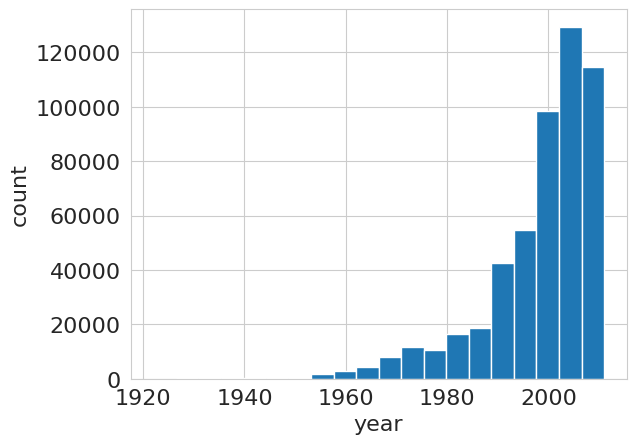

Range: 1922 - 2011
Unique values: 89


In [37]:
plt.hist(df.iloc[:, 0], bins=20)
plt.xlabel("year")
plt.ylabel("count")
plt.show()
print(f"Range: {df.iloc[:, 0].min()} - {df.iloc[:, 0].max()}")
print(f"Unique values: {np.unique(df.iloc[:, 0]).size}")

## Обучение

Разобьем данные на обучение и тест (не меняйте здесь ничего, чтобы сплит был одинаковым у всех).

In [38]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = int(0.75 * X.shape[0])
X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]
X_train.shape, X_test.shape

((386508, 90), (128837, 90))

**Задание 0 (0 баллов, но при невыполнении максимальная оценка за всю работу &mdash; 0 баллов).** Мы будем использовать MSE как метрику качества. Прежде чем обучать нейронные сети, нам нужно проверить несколько простых бейзлайнов, чтобы было с чем сравнить более сложные алгоритмы. Для этого обучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе (также пропишите текстом, какая константа будет лучшей для MSE).

In [39]:
#ridge
ridge_model = Ridge()

ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)

#константный
best_const = y_train.mean()
y_pred_constant = np.array([best_const] * len(y_test))

mse_const = mean_squared_error(y_test,y_pred_constant)
print(f"MSE (ridge)     = {round(mse_ridge,2)}")
print(f"MSE (константа) = {round(mse_const,2)}")


MSE (ridge)     = 89.75
MSE (константа) = 117.63


**Ответ:**

если взять константу меньше среднего, то для всех объектов, которые больше константы, ошибка увеличится сильнее, чем уменьшится для тех, кто ниже. Это происходит потому что квадрат штрафует большие отклонения сильнее, чем маленькие, поэтому среднее будет как бы уравгошивать эти стироны

Кстати для MAE, т.к. эта метрика берет модуль отклонения, лучше взять медиану

Теперь приступим к экспериментам с нейросетями. Для начала отделим от данных валидацию:

In [40]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=0xE2E4
)
X_train.shape, X_val.shape

((289881, 90), (96627, 90))

## Часть 1. Заводим нейронную сеть (5 баллов)

**Задание 1.1 (0.5 баллов).** Заполните пропуски в функции `train_and_validate`. Она поможет нам запускать эксперименты. Можете также реализовать поддержку обучения на GPU, чтобы эксперименты считались быстрее. Бесплатно воспользоваться GPU можно на сервисах **Google Colab** и **Kaggle**.

In [41]:
def plot_losses(train_losses, train_metrics, val_losses, val_metrics):
    """
    Plot losses and metrics while training
      - train_losses: sequence of train losses
      - train_metrics: sequence of train MSE values
      - val_losses: sequence of validation losses
      - val_metrics: sequence of validation MSE values
    """
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label="train")
    axs[0].plot(range(1, len(val_losses) + 1), val_losses, label="val")
    axs[1].plot(range(1, len(train_metrics) + 1), train_metrics, label="train")
    axs[1].plot(range(1, len(val_metrics) + 1), val_metrics, label="val")

    if max(train_losses) / min(train_losses) > 10:
        axs[0].set_yscale("log")

    if max(train_metrics) / min(train_metrics) > 10:
        axs[0].set_yscale("log")

    for ax in axs:
        ax.set_xlabel("epoch")
        ax.legend()

    axs[0].set_ylabel("loss")
    axs[1].set_ylabel("MSE")
    plt.show()


def train_and_validate(
    model,
    optimizer,
    criterion,
    metric,
    train_loader,
    val_loader,
    num_epochs,
    verbose=True,
):
    """
    Train and validate neural network
      - model: neural network to train
      - optimizer: optimizer chained to a model
      - criterion: loss function class
      - metric: function to measure MSE taking neural networks predictions
                 and ground truth labels
      - train_loader: DataLoader with train set
      - val_loader: DataLoader with validation set
      - num_epochs: number of epochs to train
      - verbose: whether to plot metrics during training
    Returns:
      - train_mse: training MSE over the last epoch
      - val_mse: validation MSE after the last epoch
    """

    # определяем, есть ли GPU. Если есть - будем считать на ней, иначе на CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # переносим модель на выбранное устройство (GPU или CPU)
    model.to(device)

    train_losses, val_losses = [], []
    train_metrics, val_metrics = [], []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss, running_metric = 0, 0
        pbar = (
            tqdm(train_loader, desc=f"Training {epoch}/{num_epochs}")
            if verbose
            else train_loader
        )

        for i, (X_batch, y_batch) in enumerate(pbar, 1):
            # переносим батч данных на то же устройство, где лежит модель
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # обнуляем градиенты с предыдущего шага, иначе они будут накапливаться
            optimizer.zero_grad()

            # forward pass: получаем предсказания модели
            predictions = model(X_batch)

            # считаем значение функции потерь между предсказаниями и истинными метками
            loss = criterion(predictions, y_batch)

            # backward pass: считаем градиенты функции потерь по всем параметрам модели
            loss.backward()

            # делаем шаг оптимизатора: обновляем веса модели, используя посчитанные градиенты
            optimizer.step()

            with torch.no_grad():
                metric_value = metric(predictions, y_batch)
                if type(metric_value) == torch.Tensor:
                    metric_value = metric_value.item()
                running_loss += loss.item() * X_batch.shape[0]
                running_metric += metric_value * X_batch.shape[0]

            if verbose and i % 100 == 0:
                pbar.set_postfix({"loss": loss.item(), "MSE": metric_value})

        train_losses += [running_loss / len(train_loader.dataset)]
        train_metrics += [running_metric / len(train_loader.dataset)]

        model.eval()
        running_loss, running_metric = 0, 0
        pbar = (
            tqdm(val_loader, desc=f"Validating {epoch}/{num_epochs}")
            if verbose
            else val_loader
        )

        for i, (X_batch, y_batch) in enumerate(pbar, 1):
            with torch.no_grad():
                # переносим батч на устройство, как и при обучении
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                # forward pass без вычисления градиентов (мы внутри torch.no_grad())
                predictions = model(X_batch)

                # считаем loss, чтобы следить за качеством на валидации
                loss = criterion(predictions, y_batch)

                metric_value = metric(predictions, y_batch)
                if type(metric_value) == torch.Tensor:
                    metric_value = metric_value.item()
                running_loss += loss.item() * X_batch.shape[0]
                running_metric += metric_value * X_batch.shape[0]

            if verbose and i % 100 == 0:
                pbar.set_postfix({"loss": loss.item(), "MSE": metric_value})

        val_losses += [running_loss / len(val_loader.dataset)]
        val_metrics += [running_metric / len(val_loader.dataset)]

        if verbose:
            plot_losses(train_losses, train_metrics, val_losses, val_metrics)

    if verbose:
        print(f"Validation MSE: {val_metrics[-1]:.3f}")

    return train_metrics[-1], val_metrics[-1]

**Задание 1.2 (0.75 балла).** Попробуем обучить нашу первую нейронную сеть. Здесь целевая переменная дискретная &mdash; это год выпуска песни. Поэтому будем учить сеть на классификацию c помощью [кросс-энтропийной функции потерь](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).

- В качестве архитектуры сети возьмите два линейных слоя с активацией ReLU между ними c числом скрытых нейронов, равным 128.
- Используйте SGD с `lr=1e-2`.
- Возьмите размер мини-батча около 32-64, примерно 3-4 эпох обучения должно быть достаточно.
- Скорее всего вам пригодится `torch.utils.data.TensorDataset`. Когда будете конвертировать numpy-массивы в torch-тензоры, используйте тип `torch.float32`.
- Также преобразуйте целевую переменную так, чтобы ее значения принимали значения от $0$ до $C-1$, где $C$ &mdash; число классов (лучше передайте преобразованное значение в TensorDataset, исходное нам еще пригодится)
- В качестве параметра `metric` в `train_and_validate` передайте lambda-выражение, которое считает MSE по выходу нейронной сети и целевой переменной. В случае классификации предсказывается класс с наибольшей вероятностью (или, что то же самое, с наибольшим значением **логита**$^1$).

$^1$ **Логит** &mdash; выход последнего линейного слоя, может принимать любые вещественные значения. Если применить Softmax к логитам, то получатся вероятности распределения классов.

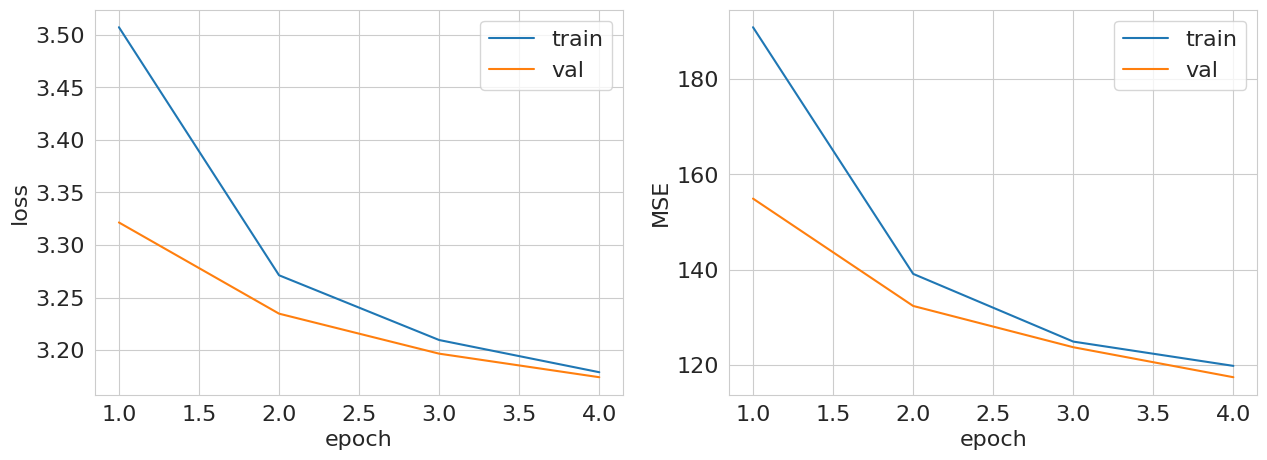

Validation MSE: 117.435


In [42]:
# для нумерации классов просто возьмем разницу между максимальным и минимальным годом это будет кол-во наших классов
year_min = int(y.min())
year_max = int(y.max())
num_classes = year_max - year_min + 1 #кол-во классов

y_train_class = (y_train - year_min).astype(np.int64)
y_val_class = (y_val - year_min).astype(np.int64)



#трансформируем признаки, ибо нейросеткам так проще
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)



#собираем тензоры
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)

#передаем новые данные в TensorDataset
y_train_tensor = torch.tensor(y_train_class, dtype=torch.long)
y_val_tensor = torch.tensor(y_val_class, dtype=torch.long)

#собираем датасеты
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

#готовим данные для нейросетки
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)



# 2 линейных слоя + ReLU на 128 нейронов
input_dim = X_train_tensor.shape[1]  #число признаков

model = nn.Sequential(
    nn.Linear(input_dim, 128),
    nn.ReLU(),
    nn.Linear(128, num_classes)
)



#метрика оценки MSE
#скатала с нейронки, я бы не додумалась так все обернуть
mse = lambda preds, y: ((preds.argmax(dim=1).float() - y.float()) ** 2).mean()



#обучаем нейронку
train_mse, val_mse = train_and_validate(
    model=model,
    optimizer=torch.optim.SGD(model.parameters(), lr=1e-2),
    criterion=nn.CrossEntropyLoss(), #функция потерь
    metric=mse,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=4
)

**Задание 1.3 (0.5 балла).** Прокомментируйте ваши наблюдения. Удалось ли побить бейзлайн? Как вы думаете, хорошая ли идея учить классификатор для этой задачи? Почему?

**Ответ:**

Лучше бейзлайна не стали, нейронка показала ошибку примерно на уровне бейзлайна
Обычная линейная регрессия с регуляризаций ридж работает луччше
  
Учить эту задачу как классификацию неверное не очень хорошо, потому что:
- есть классы с небольшим количеством объектов, поэтому классификатору сложнее определять редкие классы
- ну и мы теряем важную информацию о природе предсказываемого признака: если предсказать +/- правильный год, то это должна быть по идее небольшая ошибка. Функция потерь не согласуется с метрикой самой ошибки

**Задание 1.4 (0.75 балла).** Теперь попробуем решать задачу как регрессию. Обучите нейронную сеть на [MSE](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html).

- Используйте такие же гиперпараметры обучения.
- Когда передаете целевую переменную в TensorDataset, сделайте reshape в (-1, 1).
- Не забудьте изменить lambda-выражение, которые вы передаете в `train_and_validate`.
- Если что-то пойдет не так, можете попробовать меньшие значения `lr`.

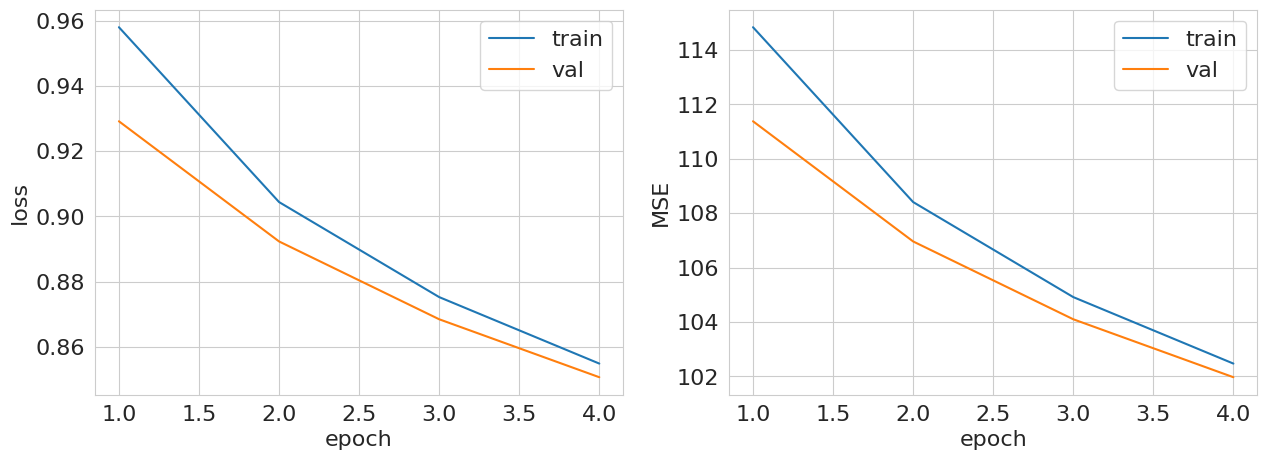

Validation MSE: 101.969
MSE train: 102.471
MSE val  : 101.969


In [43]:
#стандартизируем таргет, собираем тензоры, собираем датасеты и готовим данные для нейронки
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1))

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).reshape(-1, 1)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32).reshape(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

#создаем новую нейронку с такими же архитектурными параметрами
input_size = X_train.shape[1]

model = nn.Sequential(
    nn.Linear(input_size, 128),
    nn.ReLU(),
    nn.Linear(128, 1),
)

#все также скатала этот пункт с нейронки, вообще не поняв как это писать -_-
mse = lambda preds, y: ((preds - y) ** 2).mean() * scaler_y.scale_[0] ** 2


train_mse, val_mse = train_and_validate(
    model=model,
    optimizer=torch.optim.SGD(model.parameters(), lr=1e-4),  #с предыдущим значением lr=1e-2 MSE возвращает nan - нейросеть не сходится, поэтому снижаю lr
    criterion=nn.MSELoss(),
    metric=mse,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=4,
)

print(f"MSE train: {train_mse:.3f}")
print(f"MSE val  : {val_mse:.3f}")

**Задание 1.5 (0.5 балла).** Получилось ли у вас стабилизировать обучение? Помогли ли меньшие значения `lr`? Стало ли лучше от замены классификации на регрессию? Как вы думаете, почему так происходит? В качестве подсказки можете посмотреть на распределение целевой переменной и магнитуду значений признаков.

**Ответ:**

Функция потерь теперь согласуется с метрикой и мы получили более адекватное значение MSE на трейн выборке и валидационной
Если подходить к задаче как к регрессии, то мы не теряем природу таргета, и нейронка это лучше учитывает

Работает чуть хуже ридж, но значительно лучше константного или, когда подходили к задаче как к классификации

**Задание 1.6 (0.75 балла).** Начнем с того, что попробуем отнормировать целевую переменную. Для этого воспользуемся min-max нормализацией, чтобы целевая переменная принимала значения от 0 до 1. Реализуйте функции `normalize` и `denormalize`, которые, соответственно, нормируют целевую переменную и применяют обратное преобразование. Минимум и максимум оцените по обучающей выборке (то есть эти константы должны быть фиксированными и не зависеть от передаваемой выборки).

In [44]:
#мин и макс на обуччающей выборке
y_min = y_train.min()
y_max = y_train.max()


def normalize(sample):
    """
    Min-max normalization to convert sample to [0, 1] range
    """
    return (sample - y_min) / (y_max - y_min)


def denormalize(sample):
    """
    Denormalize sample from [0, 1] to initial range
    """
    return sample * (y_max - y_min) + y_min

Теперь повторите эксперимент из **задания 1.4**, обучаясь на нормированной целевой переменной. Сделаем также еще одно изменение: добавим [сигмоидную активацию](https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html) после последнего линейного слоя сети. Таким образом мы гарантируем, что нейронная сеть предсказывает числа из промежутка $[0, 1]$. Использование активации - довольно распространенный прием, когда мы хотим получить числа из определенного диапазона значений.

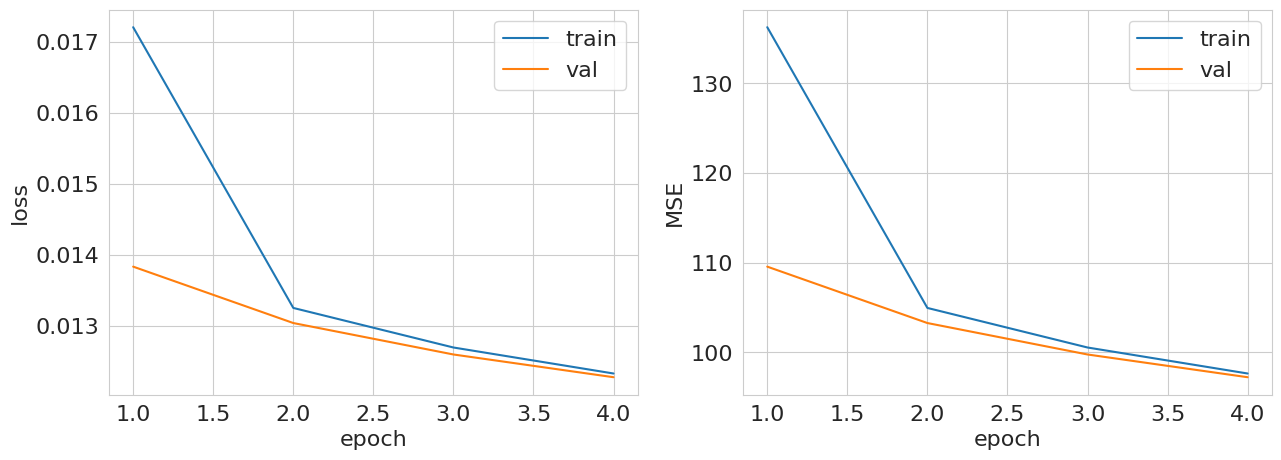

Validation MSE: 97.243
MSE train: 97.657
MSE val  : 97.243


In [45]:
# нормируем таргет по мин/макс
y_train_norm = normalize(y_train)
y_val_norm = normalize(y_val)

#потовряем упражнение, ток в архитектуру передаем функцию активации сигмоиду
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_norm, dtype=torch.float32).reshape(-1, 1)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_norm, dtype=torch.float32).reshape(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

input_size = X_train.shape[1]

model = nn.Sequential(
    nn.Linear(input_size, 128),
    nn.ReLU(),
    nn.Linear(128, 1),
    nn.Sigmoid()
)

mse = lambda preds, y: ((preds - y) ** 2).mean() * (y_max - y_min) ** 2

train_mse, val_mse = train_and_validate(
    model=model,
    optimizer=torch.optim.SGD(model.parameters(), lr=1e-2),
    criterion=nn.MSELoss(),
    metric=mse,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=4,
)

print(f"MSE train: {train_mse:.3f}")
print(f"MSE val  : {val_mse:.3f}")

**Задание 1.7 (0.5 балла).** Сравните результаты этого эксперимента с предыдущим запуском.

**Ответ:**

По сравнению с прошлым пунктом ошибка стала еще меньше. Также пробовала **убрать** сигмоиду результат был чуть лучше (97 vs 92): этот эксперемент дает понять, что более подходящий метод стандартизации может улучшить качество и мы также увидели, что неподходящие функции активации или (это в дальнейшем узнала, сча дополняю ответ) или с малым количеством эпох (нейронка может не успеть обучиться) могут негативно сказываться на качестве обучения


**Важный поинт**: если просто перезапускать модель, то она будет улучшать качество >_<. Не баг, а фича. Пошла везде приписывать модельки новые и объединять все в одну ячейку, а то где-то будет косяк 100% из-за отдельных запусков

**Задание 1.8 (0.75 балла).** На этот раз попробуем отнормировать не только целевую переменную, но и сами данные, которые подаются сети на вход. Для них будем использовать нормализацию через среднее и стандартное отклонение. Преобразуйте данные и повторите прошлый эксперимент. Скорее всего, имеет смысл увеличить число эпох обучения.

In [46]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

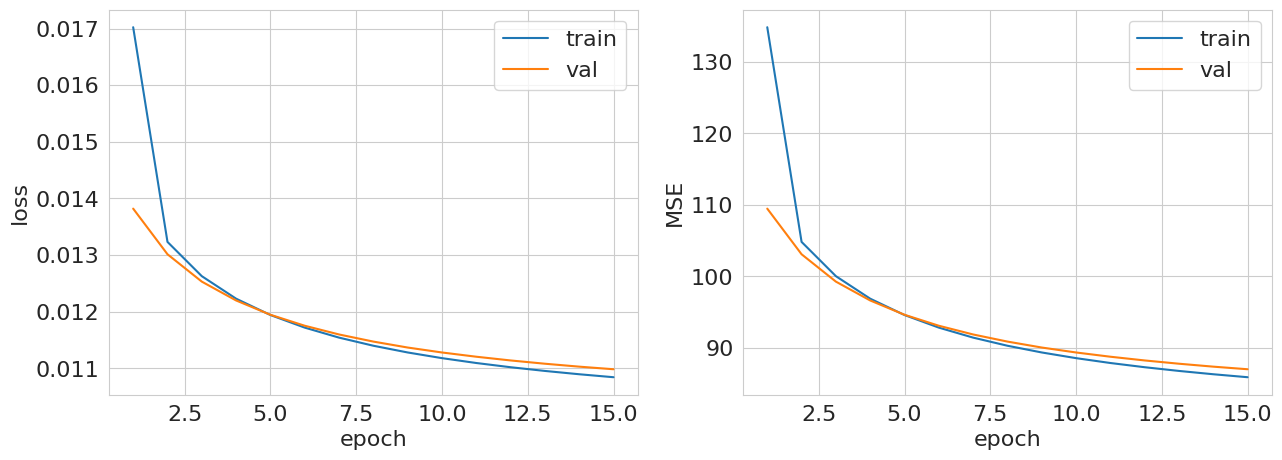

Validation MSE: 87.014
MSE train: 85.899
MSE val  : 87.014


In [47]:
y_train_norm = normalize(y_train)
y_val_norm = normalize(y_val)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_norm, dtype=torch.float32).reshape(-1, 1)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_norm, dtype=torch.float32).reshape(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

input_size = X_train.shape[1]

model = nn.Sequential(
    nn.Linear(input_size, 128),
    nn.ReLU(),
    nn.Linear(128, 1),
    nn.Sigmoid(),
)

mse = lambda preds, y: ((preds - y) ** 2).mean() * (y_max - y_min) ** 2

train_mse, val_mse = train_and_validate(
    model=model,
    optimizer=torch.optim.SGD(model.parameters(), lr=1e-2),
    criterion=nn.MSELoss(),
    metric=mse,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=15,  #преобразуем эпохи, потому что сигмоида замедляет скорость обучения модели
)

print(f"MSE train: {train_mse:.3f}")
print(f"MSE val  : {val_mse:.3f}")

Если вы все сделали правильно, то у вас должно было получиться качество, сравнимое с `Ridge` регрессией.

**Мораль:** как видите, нам пришлось сделать очень много хитрых телодвижений, чтобы нейронная сеть работала хотя бы так же, как и простая линейная модель. Здесь, конечно, показан совсем экстремальный случай, когда без нормализации данных нейронная сеть просто не учится. Как правило, в реальности завести нейронную сеть из коробки не очень сложно, но вот заставить ее работать на полную &mdash; куда более трудоемкая задача. Написание пайплайнов обучения нейросетевых моделей требует большой аккуратности, а дебаг часто превращается в угадайку. К счастью, очень часто на помощь приходит интуиция, и мы надеемся, что вы сможете выработать ее в течение нашего курса. Начнем с двух советов, которые стоит принять на вооружение:

- Обязательно начинаем любые эксперименты с бейзлайнов: без них мы бы не поняли, что нейронная сеть не учится в принципе.
- При постановке эксперментов старайтесь делать минимальное количество изменений за раз (в идеале одно!): только так можно понять, какие конкретно изменения влияют на результат.

## Часть 2. Улучшаем нейронную сеть (5 баллов)

Продолжим экспериментировать с нейронной сетью, чтобы добиться еще лучшего качества.

**Задание 2.1 (1 балл).** Давайте попробуем другие оптимизаторы. Обучите нейросеть с помощью SGD+momentum и Adam. Опишите свои наблюдения и в дальнейших запусках используйте лучший оптимизатор. Для Adam обычно берут learning rate поменьше, в районе $10^{-3}$.

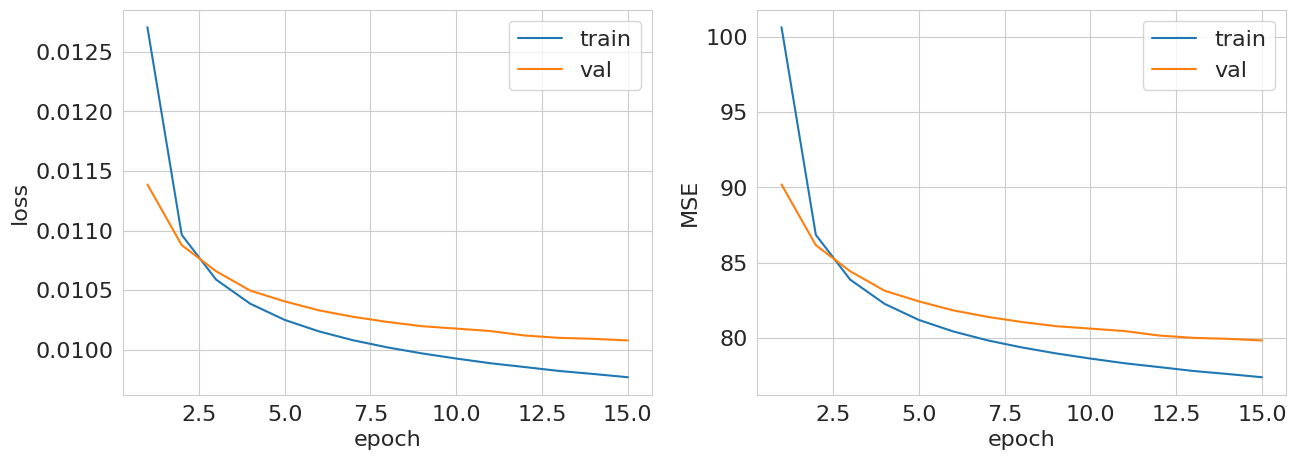

Validation MSE: 79.833
MSE train: 77.389
MSE val  : 79.833
SGD + momentum


In [48]:
input_size = X_train.shape[1]
mse = lambda preds, y: ((preds - y) ** 2).mean() * (y_max - y_min) ** 2

model_sgd_momentum = nn.Sequential(
    nn.Linear(input_size, 128),
    nn.ReLU(),
    nn.Linear(128, 1),
    nn.Sigmoid(),
)

train_mse_sgd, val_mse_sgd = train_and_validate(
    model=model_sgd_momentum,
    optimizer=torch.optim.SGD(model_sgd_momentum.parameters(), lr=1e-2, momentum=0.9),
    criterion=nn.MSELoss(),
    metric=mse,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=15,
)


print(f"MSE train: {train_mse_sgd:.3f}")
print(f"MSE val  : {val_mse_sgd:.3f}")
print("SGD + momentum")


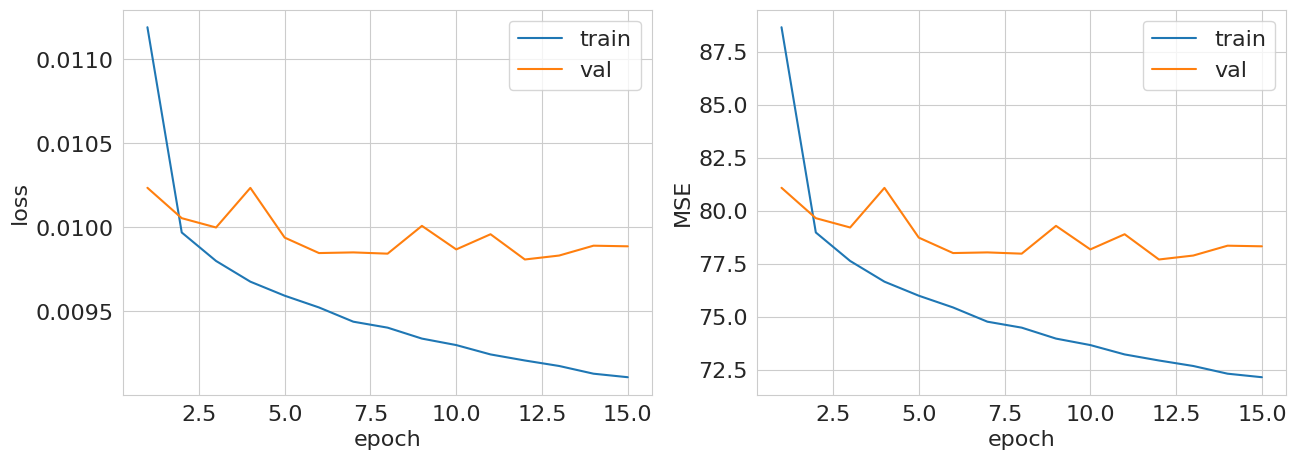

Validation MSE: 78.316
MSE train: 72.143
MSE val  : 78.316
Adam


In [49]:
model_adam = nn.Sequential(
    nn.Linear(input_size, 128),
    nn.ReLU(),
    nn.Linear(128, 1),
    nn.Sigmoid(),
)

train_mse_adam, val_mse_adam = train_and_validate(
    model=model_adam,
    optimizer=torch.optim.Adam(model_adam.parameters(), lr=1e-3),
    criterion=nn.MSELoss(),
    metric=mse,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=15,
)


print(f"MSE train: {train_mse_adam:.3f}")
print(f"MSE val  : {val_mse_adam:.3f}")
print("Adam")

SGD+momentum и Adam дают хорошее улучшение по сравнению с обычным SGD. Также стоит отметить, что кол-во эпох не изменилось, но текущая оптимизация как бы помогла сигмоиде преодолеть/вырваться из плохо обучаемой зоны

Лучшая из двух моделей Адам, её и будем использовать далее

**Задание 2.2 (1 балл).** Теперь сделаем нашу нейронную сеть более сложной. Попробуйте сделать сеть:

- более широкой (то есть увеличить размерность скрытого слоя, например, вдвое)
- более глубокой (то есть добавить еще один скрытый слой)

Опишите, как увеличение числа параметров модели влияет на качество на обучающей и валидационной выборках.

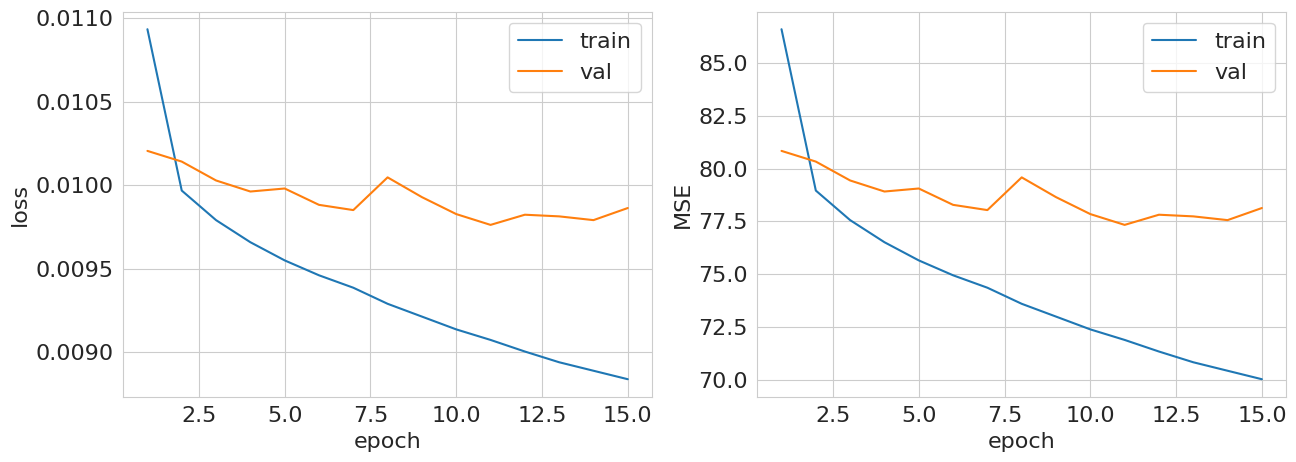

Validation MSE: 78.129
MSE train: 70.021
MSE val  : 78.129
Wide


In [50]:
#более ШИРОКАЯ сеть
model_wide = nn.Sequential(
    nn.Linear(input_size, 256),
    nn.ReLU(),
    nn.Linear(256, 1),
    nn.Sigmoid(),
)


train_mse_wide, val_mse_wide = train_and_validate(
    model=model_wide,
    optimizer=torch.optim.Adam(model_wide.parameters(), lr=1e-3),
    criterion=nn.MSELoss(),
    metric=mse,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=15,
)

print(f"MSE train: {train_mse_wide:.3f}")
print(f"MSE val  : {val_mse_wide:.3f}")
print("Wide")

Результат на трейне стал лучше, а на валидации хуже, чем был при 128 нейронах

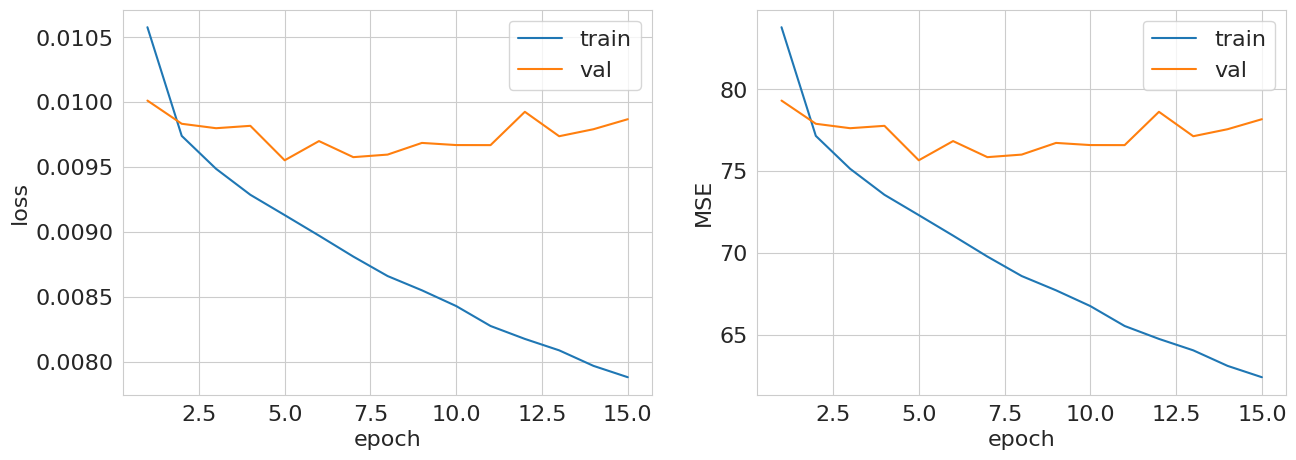

Validation MSE: 78.171
MSE train: 62.417
MSE val  : 78.171
Deep


In [51]:
# более ГЛУБОКАЯ сеть
model_deep = nn.Sequential(
    nn.Linear(input_size, 128),
    nn.ReLU(),
    nn.Linear(128, 128),  # дополнительный слой
    nn.ReLU(),
    nn.Linear(128, 1),
    nn.Sigmoid(),
)

train_mse_deep, val_mse_deep = train_and_validate(
    model=model_deep,
    optimizer=torch.optim.Adam(model_deep.parameters(), lr=1e-3),
    criterion=nn.MSELoss(),
    metric=mse,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=15,
)


print(f"MSE train: {train_mse_deep:.3f}")
print(f"MSE val  : {val_mse_deep:.3f}")
print("Deep")

Результат а валидации близок в двуслойному с 128 нейронами, на трейне результат лучше  

Здесь видим переобучение: модель с большим количеством параметров слишком хорошо подгоняется под трейн, что в дальнейшем нам сильно мешает

**Задание 2.3 (1 балл).** Как вы должны были заметить, более сложная модель стала сильнее переобучаться. Попробуем добавить в обучение регуляризацию, чтобы бороться с переобучением. Добавьте слой дропаута ([`nn.Dropout`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html#torch.nn.Dropout)) с параметром $p=0.2$ после каждого линейного слоя, кроме последнего. Почитать про дропаут можете в следующем [блогпосте](https://medium.com/@amarbudhiraja/https-medium-com-amarbudhiraja-learning-less-to-learn-better-dropout-in-deep-machine-learning-74334da4bfc5) или в оригинальной [статье](https://jmlr.org/papers/volume15/srivastava14a/srivastava14a.pdf)

Опишите результаты.

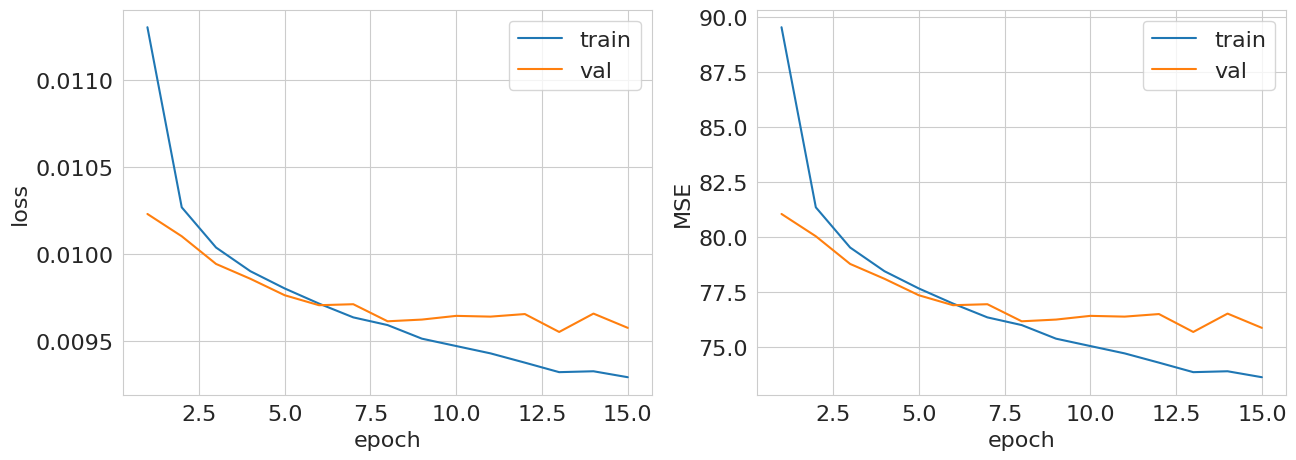

Validation MSE: 75.866
MSE train: 73.620
MSE val  : 75.866
Deep + Dropout


In [52]:
#применяем дропаут к глубокой архитектуре

model_deep_dropout = nn.Sequential(
    nn.Linear(input_size, 128),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(128, 1),
    nn.Sigmoid(),
)

train_mse_deep_drop, val_mse_deep_drop = train_and_validate(
    model=model_deep_dropout,
    optimizer=torch.optim.Adam(model_deep_dropout.parameters(), lr=1e-3),
    criterion=nn.MSELoss(),
    metric=mse,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=15,
)


print(f"MSE train: {train_mse_deep_drop:.3f}")
print(f"MSE val  : {val_mse_deep_drop:.3f}")
print("Deep + Dropout")

Результат на валидации стал заметно лучше

**Задание 2.4 (1.5 балла).** Теперь, когда мы определились с выбором архитектуры нейронной сети, пора заняться рутиной DL-инженера &mdash; перебором гиперпараметров. Подберите оптимальное значение lr по значению MSE на валидации (по логарифмической сетке, достаточно посмотреть 3-4 значения), можете воспользоваться `verbose=False` в функции `train_and_validate`.

Также подберем оптимальное значение параметра weight decay для данного lr. Weight decay &mdash; это аналог L2-регуляризации для нейронных сетей. Почитать о нем можно, например, [здесь](https://paperswithcode.com/method/weight-decay). В PyTorch он задается как параметр оптимизатора `weight_decay`. Подберите оптимальное значение weight decay по логарифимической сетке (его типичные значения лежат в диапазоне $[10^{-6}, 10^{-3}]$, но не забудьте включить нулевое значение в сетку).

Постройте графики зависимости MSE на трейне и на валидации от значений параметров. Прокомментируйте получившиеся зависимости.

In [53]:
%%time
# перебираем lr
lrs = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
lr_train, lr_val = [], []

for lr in lrs:
    torch.manual_seed(0)
    model = nn.Sequential(
        nn.Linear(X_train_scaled.shape[1], 128),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(128, 128),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(128, 1),
        nn.Sigmoid(),
    )
    train_mse_deep, val_mse_deep = train_and_validate(
        model=model,
        optimizer=torch.optim.Adam(model.parameters(), lr=lr),
        criterion=nn.MSELoss(),
        metric=mse,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=15,
        verbose=False
    )
    lr_train.append(train_mse_deep)
    lr_val.append(val_mse_deep)
    print(f"lr={lr}: train {train_mse_deep:.2f}, val {val_mse_deep:.2f}")

best_lr = lrs[np.argmin(lr_val)]
print("Лучший lr:", best_lr)

lr=0.1: train 279.30, val 280.06
lr=0.01: train 84.27, val 82.01
lr=0.001: train 73.55, val 76.34
lr=0.0001: train 75.37, val 76.26
lr=1e-05: train 84.93, val 83.35
lr=1e-06: train 103.89, val 101.07
Лучший lr: 0.0001
CPU times: user 22min 10s, sys: 815 ms, total: 22min 11s
Wall time: 22min 20s


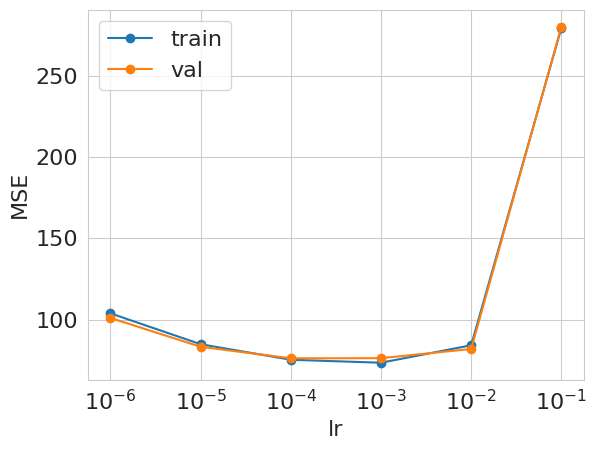

In [54]:
plt.plot(lrs, lr_train, "o-", label="train")
plt.plot(lrs, lr_val, "o-", label="val")
plt.xscale("log")
plt.xlabel("lr")
plt.ylabel("MSE")
plt.legend()
plt.show()

В целом, между lr=0.001 и lr=0.0001 разница в метрике практически отсутствует, но возьмем **lr=10^(-4)**.

Изначально сетка выглядела так: lrs = [1e-1, 1e-2, 1e-3, 1e-4]. Лучшим значением оказалось последнее, расширила сетку еще на 2 значения.
Выбор lr Не изменился, остался 10^(-4).


Перебираем дальше weight_decay:

In [55]:
%%time
# перебираем weight_decay при лучшем lr
wds = [0, 1e-6, 1e-5, 1e-4, 1e-3]
wd_train, wd_val = [], []

for wd in wds:
    torch.manual_seed(0)
    model = nn.Sequential(
        nn.Linear(X_train_scaled.shape[1], 128),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(128, 128),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(128, 1),
        nn.Sigmoid(),
    )
    train_mse_deep, val_mse_deep = train_and_validate(
        model=model,
        optimizer=torch.optim.Adam(model.parameters(), lr=best_lr, weight_decay=wd),
        criterion=nn.MSELoss(),
        metric=mse,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=15,
        verbose=False
    )
    wd_train.append(train_mse_deep)
    wd_val.append(val_mse_deep)
    print(f"weight_decay={wd}: train {train_mse_deep:.2f}, val {val_mse_deep:.2f}")

best_wd = wds[np.argmin(wd_val)]
print("Лучший weight_decay:", best_wd)

weight_decay=0: train 75.37, val 76.26
weight_decay=1e-06: train 75.29, val 76.21
weight_decay=1e-05: train 75.24, val 76.24
weight_decay=0.0001: train 77.70, val 78.47
weight_decay=0.001: train 83.55, val 83.97
Лучший weight_decay: 1e-06
CPU times: user 24min 12s, sys: 932 ms, total: 24min 13s
Wall time: 24min 38s


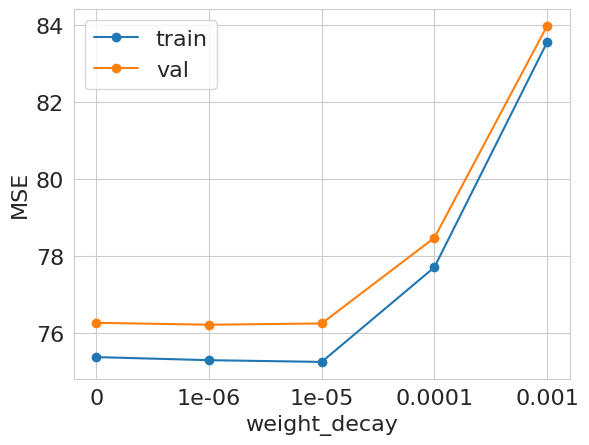

In [56]:
x = range(len(wds))
plt.plot(x, wd_train, "o-", label="train")
plt.plot(x, wd_val, "o-", label="val")
plt.xticks(x, [str(w) for w in wds]) # теги для оси поставим вручную
plt.xlabel("weight_decay")
plt.ylabel("MSE")
plt.legend()
plt.show()

По learn_rate видим, что при совсем малых значениях и совсем больших значениях из нашей сетки модель показывает не лучший результат: при экстремально малых lr модель недообучается (MSE высокая), а при больших значениях lr модель начинает расходиться и MSE так же растет.

По weight_decay видим, что при малых значениях (10^(-6) и 10^(-5)) MSE падает, но с увеличением значения, начиная с 10^(-4), регуляризация начинает быть слишком сильной и мешать обучению - MSE растет.

Как вы могли заметить, еще одна рутина DL-инженера &mdash; утомительное ожидание обучения моделей.

**Задание 2.5 (0.5 балла).** Мы провели большое число экспериментов и подобрали оптимальную архитектуру и гиперпараметры. Пришло время обучить модель на полной обучающей выборке, померять качество на тестовой выборке и сравнить с бейзлайнами. Проделайте это.

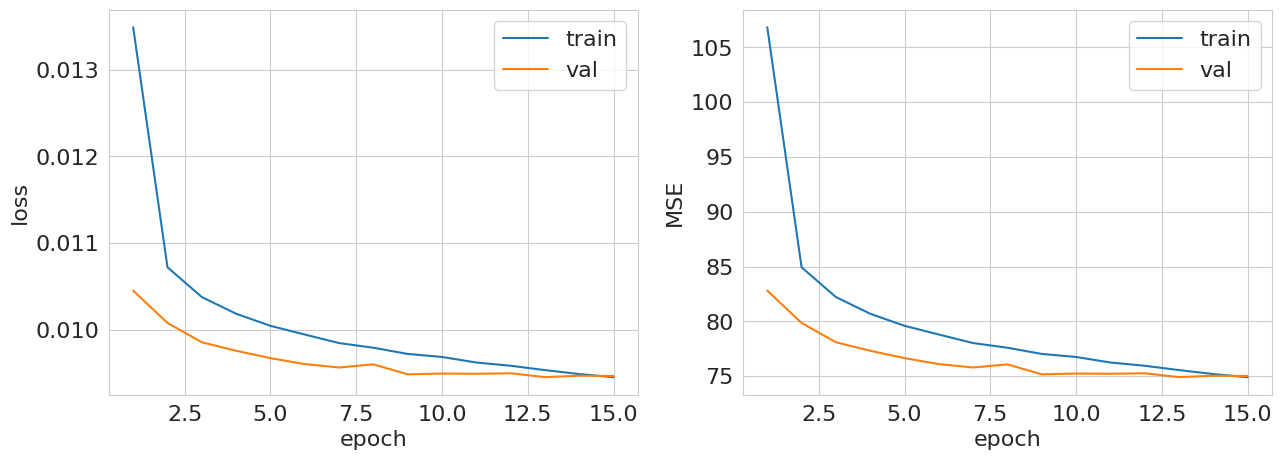

Validation MSE: 75.018
MSE Нейросеть (test): 75.02
CPU times: user 6min 26s, sys: 3 s, total: 6min 29s
Wall time: 6min 39s


In [57]:
%%time

# собираем полную обучающую выборку обратно train + val
X_full = np.concatenate([X_train, X_val])
y_full = np.concatenate([y_train, y_val])

# скейлим на фулл трейне
scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(X_full)
X_test_scaled = scaler.transform(X_test)

# так же нормализуем
y_full_norm = normalize(y_full)
y_test_norm = normalize(y_test)

X_full_tensor = torch.tensor(X_full_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_full_tensor = torch.tensor(y_full_norm, dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test_norm, dtype=torch.float32).reshape(-1, 1)

train_loader = DataLoader(TensorDataset(X_full_tensor, y_full_tensor), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64, shuffle=False)

mse = lambda predictions, y_batch: mean_squared_error(
    denormalize(predictions.detach().cpu().numpy()),
    denormalize(y_batch.detach().cpu().numpy()),
)

# финальная модель с лучшими гиперпараметрами
torch.manual_seed(0)
model = nn.Sequential(
    nn.Linear(X_full_scaled.shape[1], 128),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(128, 1),
    nn.Sigmoid(),
)

# вместо валидации грузим тест
train_mse, test_mse = train_and_validate(
    model=model,
    optimizer=torch.optim.Adam(model.parameters(), lr=best_lr, weight_decay=best_wd),
    criterion=nn.MSELoss(),
    metric=mse,
    train_loader=train_loader,
    val_loader=test_loader,
    num_epochs=15,
)
print(f"MSE Нейросеть (test): {test_mse:.2f}")

В итоге получилась модель, значительно превосходящая по качеству наш бейзлайн на тесте.

MSE при константном прогнозе = 117.63, на Ridge линрег = 89.75, а на нашей модели = 75.02

Нам удалось улучшить качество модели за счет:

1) нормализации целевой переменной
2) нормализации значений признаков
3) добавления скрытого слоя
4) добавления дропаута
5) изменения оптимизатора - выбран Adam
6) подбора гиперпараметров